# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px

# **Load Data**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/Project Datasets/Global Air Pollution Dataset_cleaned.csv')
print(f"Dataset shape: {df.shape}")
df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (23457, 12)


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good
5,United States of America,Punta Gorda,54,Moderate,1,Good,14,Good,11,Good,54,Moderate
6,Germany,Puttlingen,62,Moderate,1,Good,35,Good,3,Good,62,Moderate
7,Belgium,Puurs,64,Moderate,1,Good,29,Good,7,Good,64,Moderate
8,Russian Federation,Pyatigorsk,54,Moderate,1,Good,41,Good,1,Good,54,Moderate
9,Egypt,Qalyub,142,Unhealthy for Sensitive Groups,3,Good,89,Moderate,9,Good,142,Unhealthy for Sensitive Groups


# **Dataset Overview**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23457 entries, 0 to 23456
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23457 non-null  object
 1   City                23457 non-null  object
 2   AQI Value           23457 non-null  int64 
 3   AQI Category        23457 non-null  object
 4   CO AQI Value        23457 non-null  int64 
 5   CO AQI Category     23457 non-null  object
 6   Ozone AQI Value     23457 non-null  int64 
 7   Ozone AQI Category  23457 non-null  object
 8   NO2 AQI Value       23457 non-null  int64 
 9   NO2 AQI Category    23457 non-null  object
 10  PM2.5 AQI Value     23457 non-null  int64 
 11  PM2.5 AQI Category  23457 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


In [ ]:
df.describe().round(2)

,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23457.00,23457.00,23457.00,23457.00,23457.00
mean,72.01,1.37,35.19,3.06,68.52
std,56.06,1.83,28.10,5.25,54.80
min,6.00,0.00,0.00,0.00,0.00
25%,39.00,1.00,21.00,0.00,35.00
50%,55.00,1.00,31.00,1.00,54.00
75%,79.00,1.00,40.00,4.00,79.00
max,500.00,133.00,235.00,91.00,500.00


In [ ]:
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


# **Distribution & Overview of AQI**

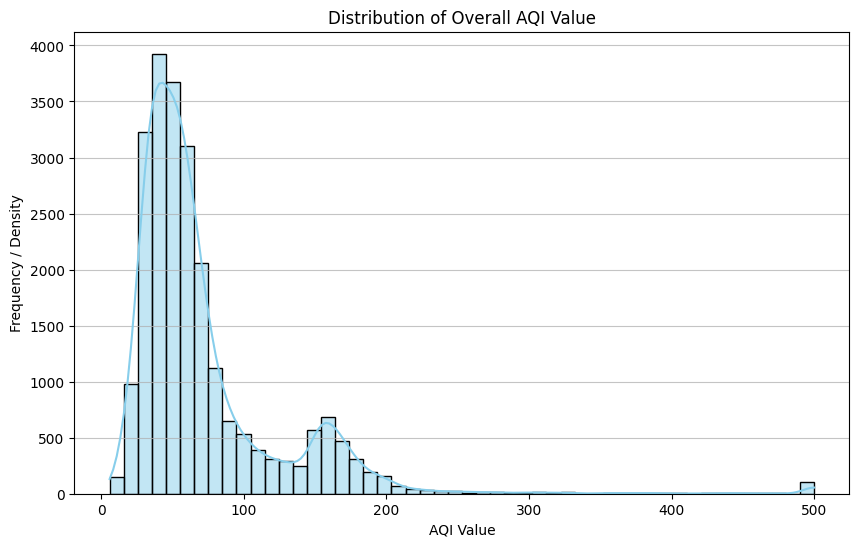

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['AQI Value'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Overall AQI Value')
plt.xlabel('AQI Value')
plt.ylabel('Frequency / Density')
plt.grid(axis='y', alpha=0.75)
plt.show()

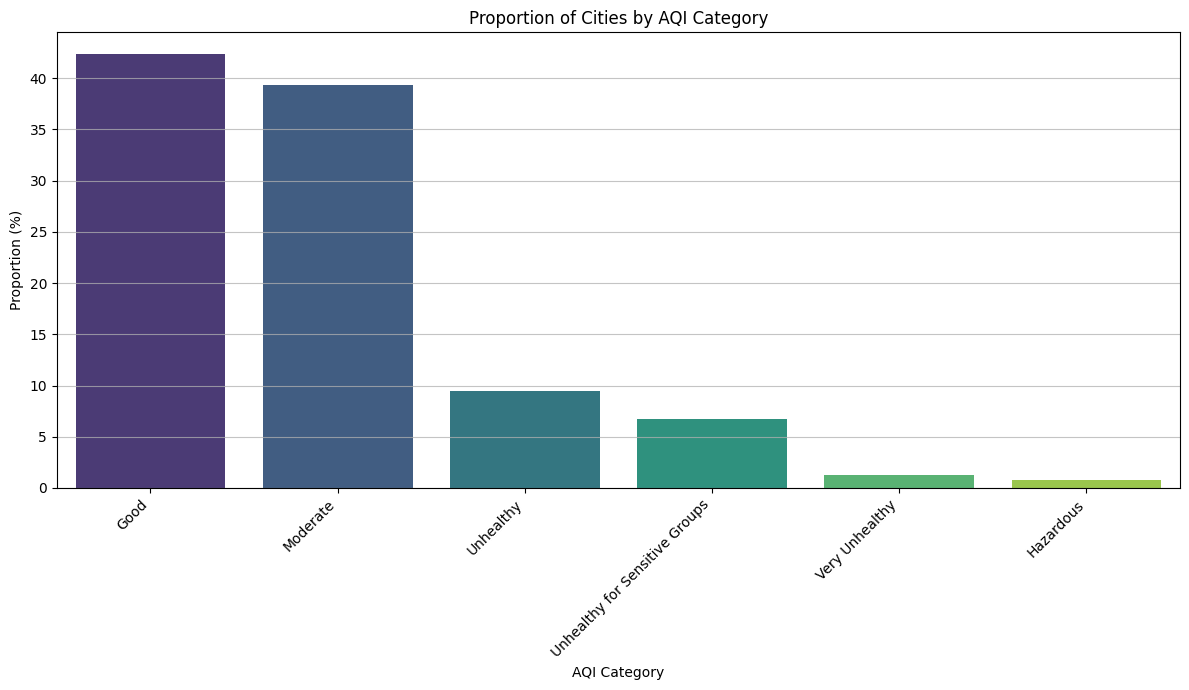

In [ ]:
aqi_category_proportions = df['AQI Category'].value_counts(normalize=True) * 100

plt.figure(figsize=(12, 7))
sns.barplot(x=aqi_category_proportions.index, y=aqi_category_proportions.values, hue=aqi_category_proportions.index, palette='viridis', legend=False)
plt.title('Proportion of Cities by AQI Category')
plt.xlabel('AQI Category')
plt.ylabel('Proportion (%)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()

# **Geographic Comparisons**

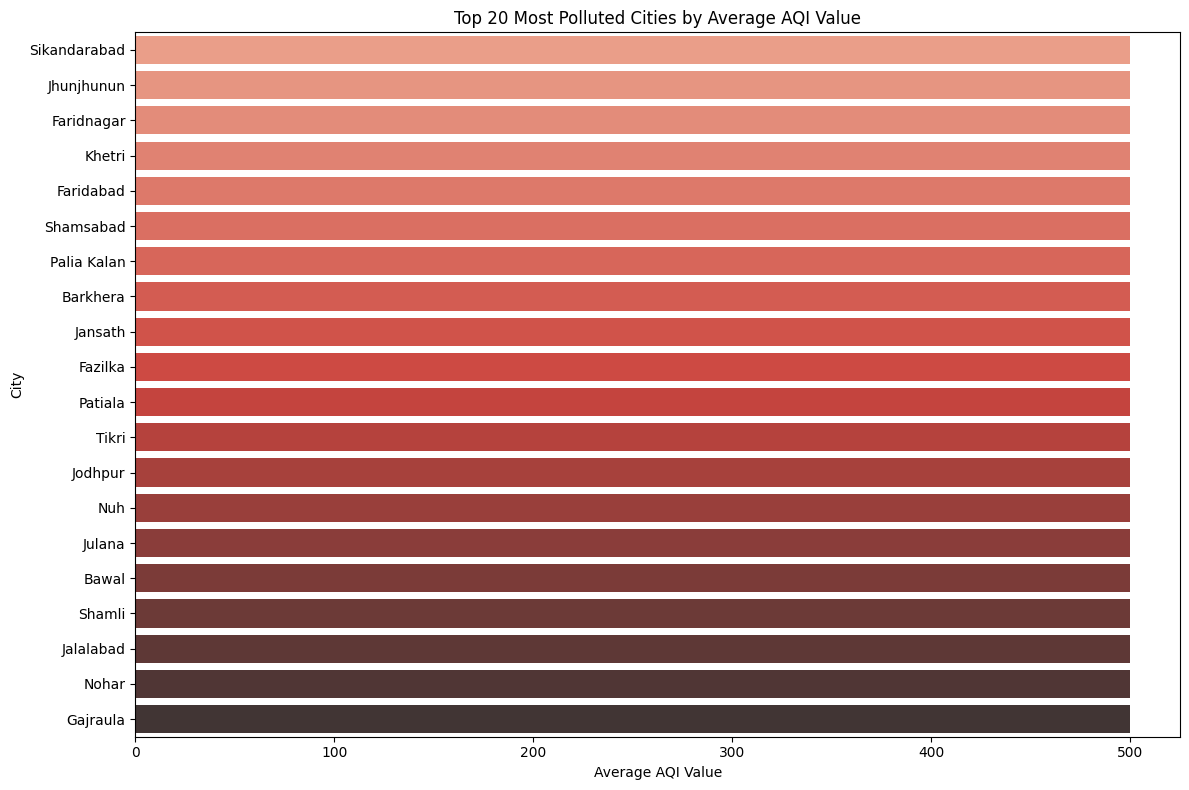

In [ ]:
top_20_cities = df.groupby('City')['AQI Value'].mean().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_20_cities.values, y=top_20_cities.index, hue=top_20_cities.index, palette='Reds_d', legend=False)
plt.title('Top 20 Most Polluted Cities by Average AQI Value')
plt.xlabel('Average AQI Value')
plt.ylabel('City')
plt.tight_layout()
plt.show()

In [ ]:
country_aqi = df.groupby('Country')['AQI Value'].mean().reset_index()

fig = px.choropleth(country_aqi,
                    locations="Country",
                    locationmode="country names",
                    color="AQI Value",
                    hover_name="Country",
                    color_continuous_scale=px.colors.sequential.Plasma,
                    title='Average AQI Value by Country')
fig.show()

# **Pollutant Relationships & Correlation**

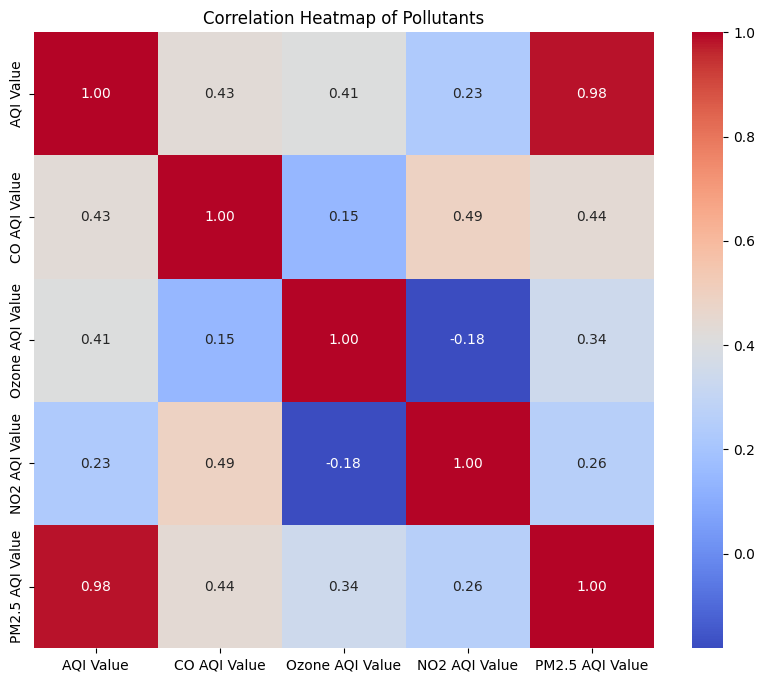

In [ ]:
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Pollutants')
plt.show()

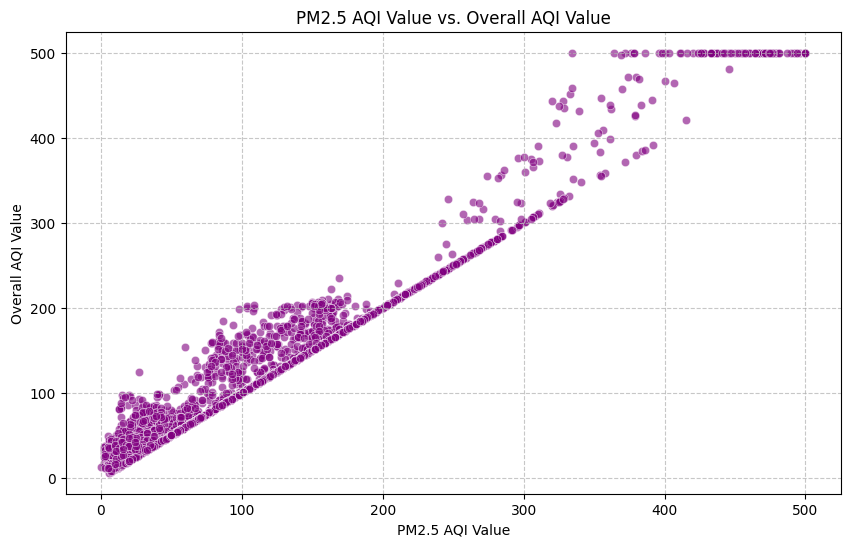

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PM2.5 AQI Value', y='AQI Value', data=df, alpha=0.6, color='purple')
plt.title('PM2.5 AQI Value vs. Overall AQI Value')
plt.xlabel('PM2.5 AQI Value')
plt.ylabel('Overall AQI Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

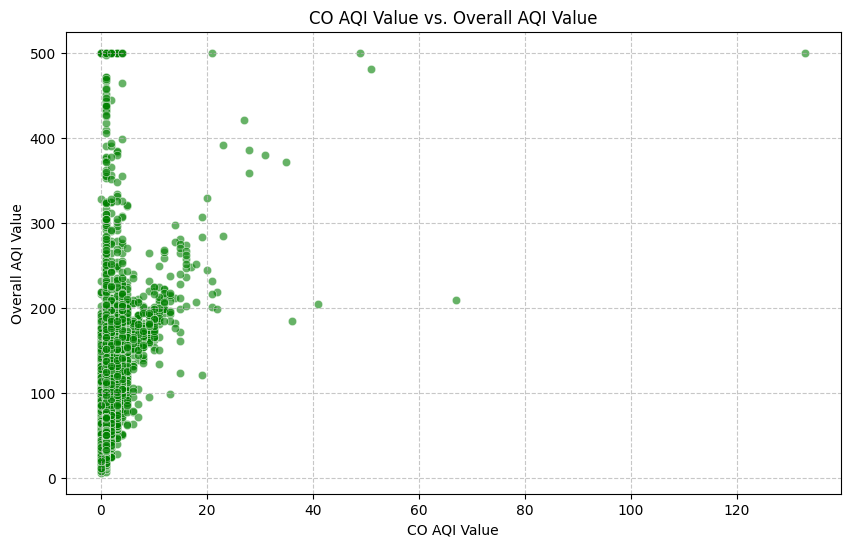

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='CO AQI Value', y='AQI Value', data=df, alpha=0.6, color='green')
plt.title('CO AQI Value vs. Overall AQI Value')
plt.xlabel('CO AQI Value')
plt.ylabel('Overall AQI Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

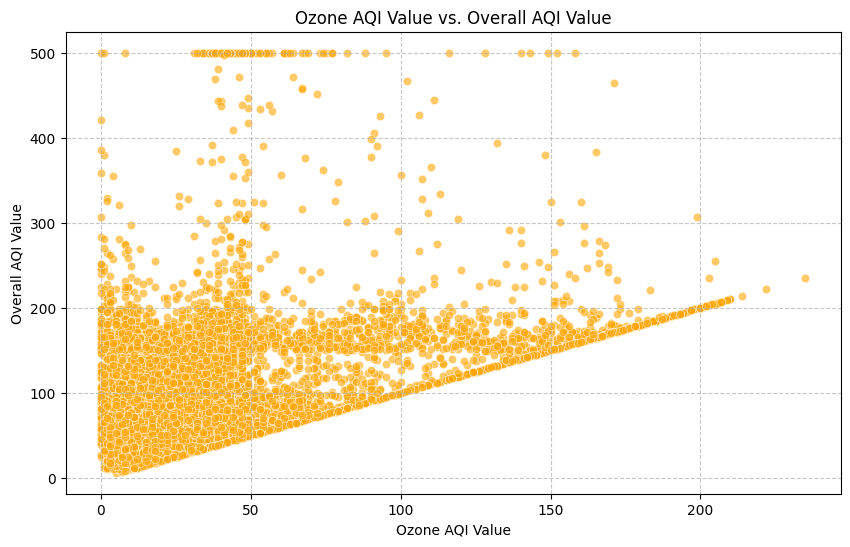

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Ozone AQI Value', y='AQI Value', data=df, alpha=0.6, color='orange')
plt.title('Ozone AQI Value vs. Overall AQI Value')
plt.xlabel('Ozone AQI Value')
plt.ylabel('Overall AQI Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

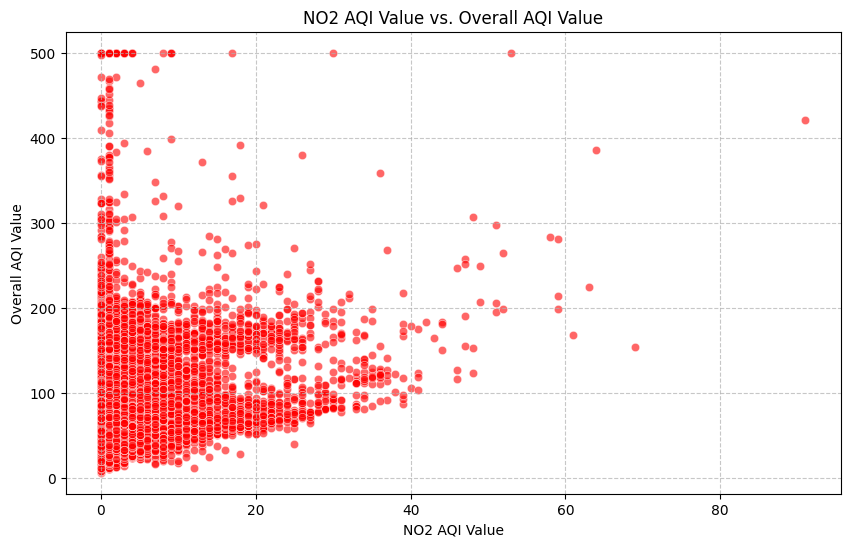

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='NO2 AQI Value', y='AQI Value', data=df, alpha=0.6, color='red')
plt.title('NO2 AQI Value vs. Overall AQI Value')
plt.xlabel('NO2 AQI Value')
plt.ylabel('Overall AQI Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# **Pollutant Profiles Comparison**

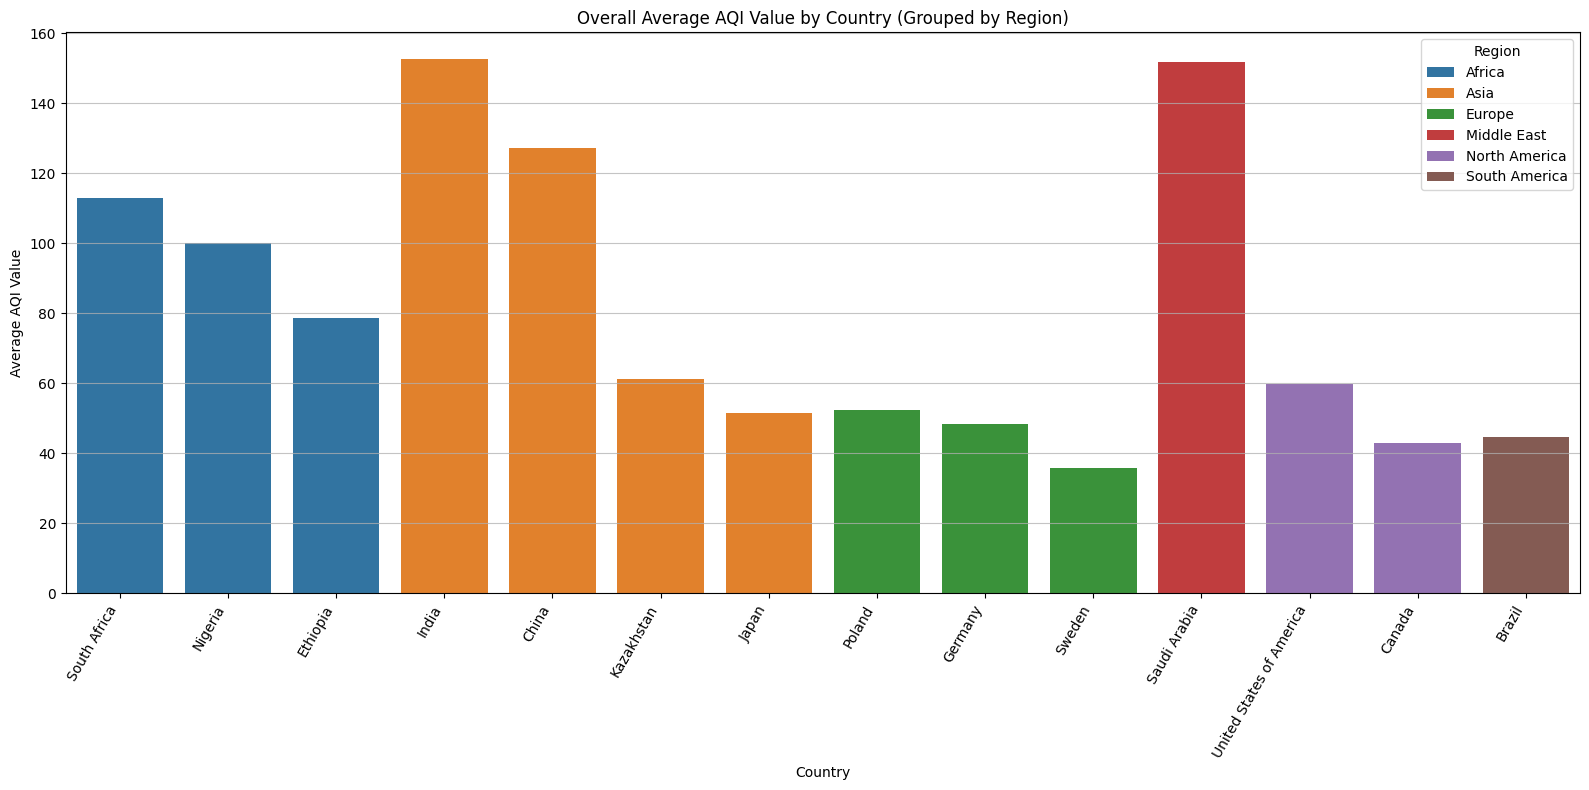

In [ ]:
countries_for_bar_chart = {
    'India': 'Asia',
    'China': 'Asia',
    'Japan': 'Asia',
    'Germany': 'Europe',
    'Poland': 'Europe',
    'Sweden': 'Europe',
    'United States of America': 'North America',
    'Brazil': 'South America',
    'Canada': 'North America',
    'Nigeria': 'Africa',
    'South Africa': 'Africa',
    'Ethiopia': 'Africa',
    'Saudi Arabia': 'Middle East',
    'Iran': 'Middle East',
    'Kazakhstan': 'Asia'
}

filtered_df_bar = df[df['Country'].isin(countries_for_bar_chart.keys())].copy()

country_aqi_bar = filtered_df_bar.groupby('Country')['AQI Value'].mean().reset_index()

country_aqi_bar['Region'] = country_aqi_bar['Country'].map(countries_for_bar_chart)

country_aqi_bar = country_aqi_bar.sort_values(by=['Region', 'AQI Value'], ascending=[True, False])

plt.figure(figsize=(16, 8))
sns.barplot(x='Country', y='AQI Value', hue='Region', data=country_aqi_bar, palette='tab10', dodge=False)
plt.title('Overall Average AQI Value by Country (Grouped by Region)')
plt.xlabel('Country')
plt.ylabel('Average AQI Value')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()


,PM2.5 AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value
Country,,,,
India,0.973482,0.274998,0.569162,0.163785
Nigeria,0.495934,1.000000,0.000000,0.209603
Poland,0.000000,0.000000,0.173877,0.101090
Saudi Arabia,1.000000,0.112590,1.000000,0.000000
United States of America,0.085787,0.178307,0.053338,1.000000


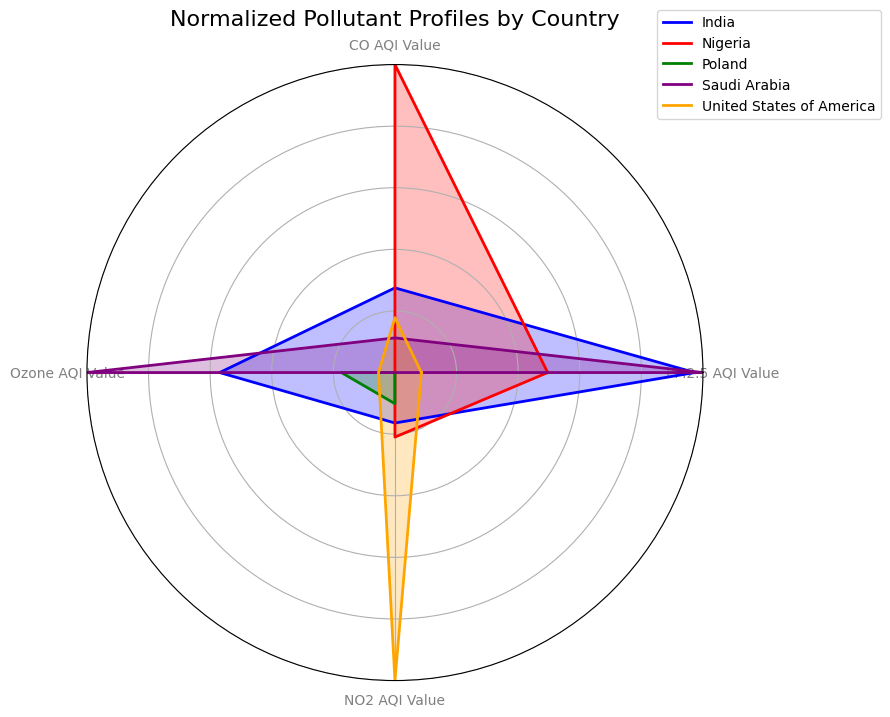

In [ ]:
countries_for_radar_chart = ['India', 'Poland', 'United States of America', 'Nigeria', 'Saudi Arabia']
pollutant_cols = ['PM2.5 AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value']

filtered_df_radar = df[df['Country'].isin(countries_for_radar_chart)].copy()

country_pollutants = filtered_df_radar.groupby('Country')[pollutant_cols].mean().reset_index()

scaler = MinMaxScaler()
country_pollutants_normalized = pd.DataFrame(scaler.fit_transform(country_pollutants[pollutant_cols]),
                                             columns=pollutant_cols,
                                             index=country_pollutants['Country'])
display(country_pollutants_normalized.head())

def create_radar_chart(data, ax, color, label):
    categories = list(data.index)
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    values = data.values.flatten().tolist()
    values += values[:1]

    ax.plot(angles, values, color=color, linewidth=2, linestyle='solid', label=label)
    ax.fill(angles, values, color=color, alpha=0.25)

    ax.set_yticklabels([])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, color='grey', size=10)
    ax.set_ylim(0, 1)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ['blue', 'red', 'green', 'purple', 'orange']

for i, (country, row) in enumerate(country_pollutants_normalized.iterrows()):
    create_radar_chart(row, ax, colors[i], country)

plt.title('Normalized Pollutant Profiles by Country', size=16, color='black', y=1.05)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

# Key EDA Findings Summary

| Finding Category          | Key Insight                                                                                                |
| :------------------------ | :--------------------------------------------------------------------------------------------------------- |
| **Overall AQI Distribution** | Majority of cities fall into 'Good' (42%) and 'Moderate' (39%) AQI categories, but a significant tail shows very high pollution levels (e.g., Hazardous, Very Unhealthy). |
| **Top Polluted Cities**   | Several cities, predominantly from India, show the highest possible AQI value (500), indicating severe air quality issues. |
| **Geographical Patterns** | The choropleth map reveals regional variations in average AQI, with certain countries consistently showing higher pollution. |
| **Pollutant Correlations**| 'PM2.5 AQI Value' exhibits the strongest positive correlation with the 'Overall AQI Value', followed by 'CO AQI Value'. This suggests they are major drivers of overall air quality. |
| **Regional AQI Comparison** | Grouped bar charts showed varying average AQI values across different countries and regions, confirming localized air quality conditions. |
| **Pollutant Profiles**    | Radar charts illustrate distinct pollutant profiles for different countries, meaning the mix and intensity of PM2.5, CO, Ozone, and NO2 vary significantly by location. |
